# Profitable Entertainment App for the App Store Vs Google Play Markets


   We're analysing for a company that builds Entertainment app for Android and iOS mobile. We make our apps available on Google Play and the App Store.

   We only build apps that are free to download and install, and our main source of revenue consists of in-app ads. This means our revenue for any given app is mostly influenced by the number of users who use our app. Our goal for this project is to analyze for the Entertainment genre, which app store has higher revenue potential?

# Opening and Exploring the Data

In [1]:
import pandas as pd

apple_store = pd.read_csv("AppleStore1.csv")
googlep_store = pd.read_csv("googleplaystore.csv")


In [2]:
apple_store.head(5)

,Unnamed: 0,id,track_name,Installation,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,1,281656475,PAC-MAN Premium,100788224,USD,3.99,21292,26,4.0,4.5,6.3.5,4+,Games,38,5,10,1
1,2,281796108,Evernote - stay organized,158578688,USD,0.00,161065,26,4.0,3.5,8.2.2,4+,Productivity,37,5,23,1
2,3,281940292,"WeatherBug - Local Weather, Radar, Maps, Alerts",100524032,USD,0.00,188583,2822,3.5,4.5,5.0.0,4+,Weather,37,5,3,1
3,4,282614216,"eBay: Best App to Buy, Sell, Save! Online Shop...",128512000,USD,0.00,262241,649,4.0,4.5,5.10.0,12+,Shopping,37,5,9,1
4,5,282935706,Bible,92774400,USD,0.00,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,1


In [3]:
apple_store.shape

(7197, 17)

In [4]:
googlep_store.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
googlep_store.shape

(10841, 13)

In [6]:
googlep_store.dtypes

App                   str
Category              str
Rating            float64
Reviews               str
Size                  str
Installs              str
Type                  str
Price                 str
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object

# Removing redundant Columns

   
   
   We have 7197 iOS apps in this data set, and the columns that seem interesting are:
    'track_name', 'Installation', 'user_rating', and 'prime_genre'
    
    
    

In [7]:
apple_store1 = apple_store[apple_store["price"]== 0][['track_name','Installation','user_rating','prime_genre']]

In [8]:
apple_store1.head(2)


,track_name,Installation,user_rating,prime_genre
1,Evernote - stay organized,158578688,4.0,Productivity
2,"WeatherBug - Local Weather, Radar, Maps, Alerts",100524032,3.5,Weather




We see that the Google Play data set has 10841 apps and 13 columns. At a quick glance, the columns that might be useful for the purpose of our analysis are
'App', 'Category', 'Reviews', 'Installs' and 'Genres'.



In [9]:
googlep_store["Type"].value_counts()

Type
Free    10039
Paid      800
0           1
Name: count, dtype: int64

In [10]:
googlep_store1 = googlep_store[googlep_store["Type"]== "Free"][['App','Rating','Installs','Genres']]
del googlep_store
googlep_store1.head(2)

,App,Rating,Installs,Genres
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,"10,000+",Art & Design
1,Coloring book moana,3.9,"500,000+",Art & Design;Pretend Play


In [11]:
googlep_store1['App'].shape

(10039,)

# Data Cleaning 

## Google Store 

In [12]:
googlep_store1[googlep_store1['Rating']>5]

,App,Rating,Installs,Genres


In [13]:
googlep_store1['App'].unique()

<StringArray>
[    'Photo Editor & Candy Camera & Grid & ScrapBook',
                                'Coloring book moana',
 'U Launcher Lite – FREE Live Cool Themes, Hide Apps',
                              'Sketch - Draw & Paint',
              'Pixel Draw - Number Art Coloring Book',
                         'Paper flowers instructions',
            'Smoke Effect Photo Maker - Smoke Editor',
                                   'Infinite Painter',
                               'Garden Coloring Book',
                      'Kids Paint Free - Drawing Fun',
 ...
                           'payermonstationnement.fr',
                                           'FR Tides',
                                        'Chemin (fr)',
                                      'FR Calculator',
                                           'FR Forms',
                                   'Sya9a Maroc - FR',
                   'Fr. Mike Schmitz Audio Teachings',
                             'Parkinson Exerci

In [14]:
googlep_store1['Installs'].unique()

<StringArray>
[       '10,000+',       '500,000+',     '5,000,000+',    '50,000,000+',
       '100,000+',        '50,000+',     '1,000,000+',    '10,000,000+',
         '5,000+',   '100,000,000+', '1,000,000,000+',         '1,000+',
   '500,000,000+',           '500+',           '100+',            '50+',
            '10+',             '1+',             '5+',             '0+']
Length: 20, dtype: str

In [15]:
googlep_store1['Genres'].unique()

<StringArray>
[                   'Art & Design',       'Art & Design;Pretend Play',
         'Art & Design;Creativity', 'Art & Design;Action & Adventure',
                 'Auto & Vehicles',                          'Beauty',
               'Books & Reference',                        'Business',
                          'Comics',               'Comics;Creativity',
 ...
             'Lifestyle;Education',         'Card;Action & Adventure',
     'Books & Reference;Education',            'Simulation;Education',
                'Puzzle;Education',        'Role Playing;Brain Games',
              'Strategy;Education',             'Racing;Pretend Play',
        'Communication;Creativity',             'Strategy;Creativity']
Length: 115, dtype: str

# Google Store Data Report :
1.Install column is not an exact number. It contains buckets such 10,000+ . So Create a numeric lower-bound column:
'Install_Lower_Bound'                
2.Rating column has vaue  19.It cannot be valid because ratings should be between 0 and 5.                   
3.Dataset also has duplicates and missing values             
4.Convert reviews to numeric type

In [16]:

# -------------------------------
# Convert Rating
# -------------------------------

googlep_store1["Rating"] = pd.to_numeric(
    googlep_store1["Rating"],
    errors="coerce"
)

# Remove invalid rating records
googlep_store1 = googlep_store1[
    googlep_store1["Rating"].isna() |
    googlep_store1["Rating"].between(0, 5)
]

# -------------------------------
# Convert Installs
# -------------------------------

googlep_store1["Installation"] = (
    googlep_store1["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

googlep_store1 = googlep_store1.drop("Installs",axis=1)
googlep_store1["Installation"] = pd.to_numeric(
    googlep_store1["Installation"],
    errors="coerce"
)

# -------------------------------
# Remove missing values
# -------------------------------

googlep_store1 = googlep_store1.dropna(
    subset=["App", "Genres", "Installation"]
)




In [17]:

googlep_store1["Genres"] = googlep_store1["Genres"].str.split(';').str[0]

In [18]:
googlep_store1.head()

,App,Rating,Genres,Installation
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,Art & Design,10000
1,Coloring book moana,3.9,Art & Design,500000
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4.7,Art & Design,5000000
3,Sketch - Draw & Paint,4.5,Art & Design,50000000
4,Pixel Draw - Number Art Coloring Book,4.3,Art & Design,100000


## Apple Store

In [19]:
apple_store1.head(2)

,track_name,Installation,user_rating,prime_genre
1,Evernote - stay organized,158578688,4.0,Productivity
2,"WeatherBug - Local Weather, Radar, Maps, Alerts",100524032,3.5,Weather


In [20]:
apple_store1['track_name'].unique()

<StringArray>
[                         'Evernote - stay organized',
    'WeatherBug - Local Weather, Radar, Maps, Alerts',
 'eBay: Best App to Buy, Sell, Save! Online Shopping',
                                              'Bible',
             'PayPal - Send and request money safely',
                            'Pandora - Music & Radio',
               'Google – Search made just for mobile',
                   'Bank of America - Mobile Banking',
             'TripAdvisor Hotels Flights Restaurants',
                                           'Facebook',
 ...
                   'Laurie Hernandez the Human Emoji',
                                  'camera for filter',
                                    '剑客情缘-高爆率高掉落天天疯玩',
                 '脱出ゲーム - 書道教室 -  "漢字"の謎に満ちた部屋からの 脱出',
                          'Escape Game: illumination',
       'Demolition Derby Virtual Reality (VR) Racing',
                                              'Kubik',
                                  'VR Roller-C

In [21]:
apple_store1['user_rating'].unique()

array([4. , 3.5, 4.5, 3. , 2. , 2.5, 1.5, 0. , 5. , 1. ])

In [22]:
apple_store1[apple_store1['user_rating'] < 0]

,track_name,Installation,user_rating,prime_genre


In [23]:
apple_store1['prime_genre'].unique()

<StringArray>
[     'Productivity',           'Weather',          'Shopping',
         'Reference',           'Finance',             'Music',
         'Utilities',            'Travel', 'Social Networking',
            'Sports',  'Health & Fitness',             'Games',
      'Food & Drink',              'News',              'Book',
     'Photo & Video',     'Entertainment',          'Business',
         'Lifestyle',         'Education',        'Navigation',
           'Medical',          'Catalogs']
Length: 23, dtype: str

# Apple Store Data Report




1. The company  builds apps that are free to download and install, and that are directed toward an English-speaking audience. This means that we'll need to:

* Remove non-English apps like 爱奇艺PPS -《欢乐颂2》电视剧热播
2. Removing duplicates


In [24]:
apple_store1["track_name"].value_counts().head()


track_name
VR Roller Coaster                                     2
Mannequin Challenge                                   2
Evernote - stay organized                             1
WeatherBug - Local Weather, Radar, Maps, Alerts       1
eBay: Best App to Buy, Sell, Save! Online Shopping    1
Name: count, dtype: int64

# Track_name Cleaning 

In [25]:
apple_store1["non_english"]=apple_store1["track_name"].str.contains(
    r"[^\x00-\x7F]",
    regex=True,
    na=False
)
# Keep English-oriented app names
apple_store1 = apple_store1[
    ~apple_store1["non_english"]
].copy()


In [26]:
apple_store1["track_name"].values

<StringArray>
[                         'Evernote - stay organized',
    'WeatherBug - Local Weather, Radar, Maps, Alerts',
 'eBay: Best App to Buy, Sell, Save! Online Shopping',
                                              'Bible',
             'PayPal - Send and request money safely',
                            'Pandora - Music & Radio',
                   'Bank of America - Mobile Banking',
             'TripAdvisor Hotels Flights Restaurants',
                                           'Facebook',
     'Yelp - Nearby Restaurants, Shopping & Services',
 ...
                                 'Human Juggling Cup',
                           'Again - room escape game',
                   'Laurie Hernandez the Human Emoji',
                                  'camera for filter',
                          'Escape Game: illumination',
       'Demolition Derby Virtual Reality (VR) Racing',
                                              'Kubik',
                                  'VR Roller-C

# Deleting the duplicates

 The apple store data has 2 duplicates .We are deleting the duplicates by taking the values which has 
    the highest count of reviews since it will be the recent review

In [27]:
apple_store1["track_name"].shape

(2922,)

In [28]:
apple_store1["track_name"].unique().shape

(2920,)

In [29]:
apple_store1["track_name"].value_counts()

track_name
VR Roller Coaster                                     2
Mannequin Challenge                                   2
Evernote - stay organized                             1
WeatherBug - Local Weather, Radar, Maps, Alerts       1
eBay: Best App to Buy, Sell, Save! Online Shopping    1
                                                     ..
Demolition Derby Virtual Reality (VR) Racing          1
Kubik                                                 1
VR Roller-Coaster                                     1
VR Roller Coaster World - Virtual Reality             1
Escape the Sweet Shop Series                          1
Name: count, Length: 2920, dtype: int64

In [30]:
apple_store1 = (
    apple_store1.sort_values(
        ["track_name", "Installation"],
        ascending=[True, False]
    )
    .drop_duplicates(
        subset=["track_name"],
        keep="first"
    )
    .reset_index(drop=True)
)

In [31]:
apple_store1["track_name"].shape

(2920,)

In [32]:
apple_store1["track_name"].value_counts()

track_name
! OH Fantastic Free Kick + Kick Wall Challenge    1
*Solitaire*                                       1
. Calculator .                                    1
1+2=3                                             1
1-Bit Rogue: A dungeon crawler RPG!               1
                                                 ..
slither.io                                        1
splix.io!                                         1
theSkimm                                          1
vente-privee                                      1
wetter.com                                        1
Name: count, Length: 2920, dtype: int64

In [33]:
apple_store1 = apple_store1.rename(
    columns={"prime_genre": "Genre","user_rating":"Rating","track_name":"App"}
)

apple_store1 = apple_store1.drop("non_english",axis=1)
apple_store1.head(1)

,App,Installation,Rating,Genre
0,! OH Fantastic Free Kick + Kick Wall Challenge,162557952,0.0,Games


In [34]:
googlep_store1 = googlep_store1.rename(
    columns={"Genres": "Genre"}
)

# Exploratory Data Analysis

# Google Play store

In [35]:
googlep_store1.head(1)

,App,Rating,Genre,Installation
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,Art & Design,10000


In [36]:
apple_store1.head(1)

,App,Installation,Rating,Genre
0,! OH Fantastic Free Kick + Kick Wall Challenge,162557952,0.0,Games


In [37]:
import pandas as pd
import matplotlib.pyplot as plt


# Combine both datasets
comparison = pd.merge(
    apple_store1,
    googlep_store1,
    on="Genre",
    how="outer",
    suffixes=("_Apple", "_Google")
).fillna(0)

comparison.head(2)

,App_Apple,Installation_Apple,Rating_Apple,Genre,App_Google,Rating_Google,Installation_Google
0,0,0.0,0.0,Action,slither.io,4.4,100000000.0
1,0,0.0,0.0,Action,Temple Run 2,4.3,500000000.0


In [38]:
comparison = comparison[["Genre","App_Apple","App_Google","Installation_Google","Installation_Apple","Rating_Google","Rating_Apple"]]
comparison.head(1)

,Genre,App_Apple,App_Google,Installation_Google,Installation_Apple,Rating_Google,Rating_Apple
0,Action,0,slither.io,100000000.0,0.0,4.4,0.0


# Entertainment apps for Google vs Apple Store

In [39]:
comparison = comparison[comparison["Genre"] == "Entertainment"]

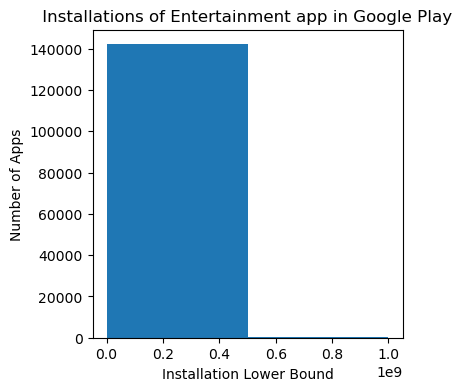

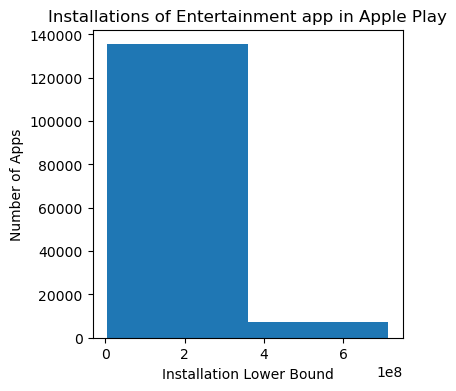

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))

plt.hist(
    comparison["Installation_Google"].dropna(),
    bins=2
)

plt.title(" Installations of Entertainment app in Google Play ")
plt.xlabel("Installation Lower Bound")
plt.ylabel("Number of Apps")

plt.show()



plt.figure(figsize=(4, 4))

plt.hist(
    comparison["Installation_Apple"].dropna(),
    bins=2
)

plt.title("Installations of Entertainment app in Apple Play")
plt.xlabel("Installation Lower Bound")
plt.ylabel("Number of Apps")

plt.show()

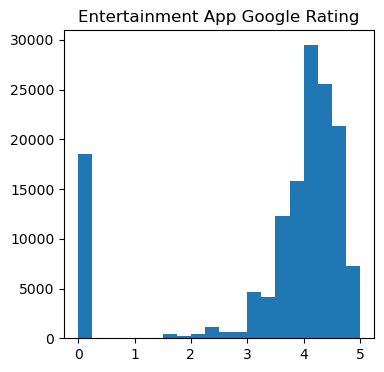

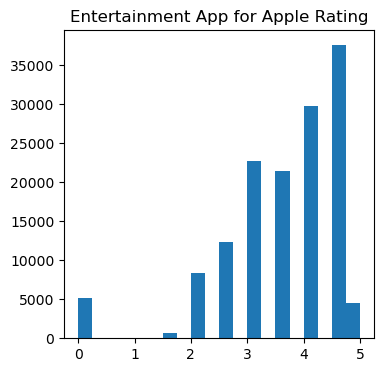

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))

plt.hist(
    comparison["Rating_Google"].dropna(),
    bins=20
)

plt.title("Entertainment App Google Rating")

plt.show()

import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))

plt.hist(
    comparison["Rating_Apple"].dropna(),
    bins=20
)

plt.title("Entertainment App for Apple Rating")

plt.show()

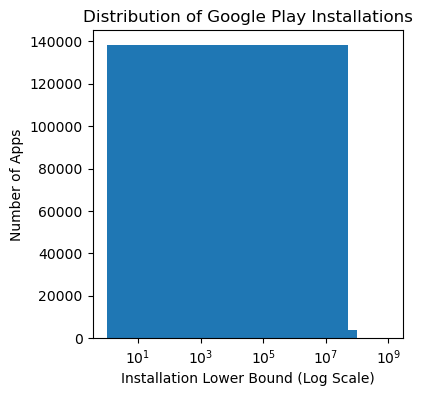

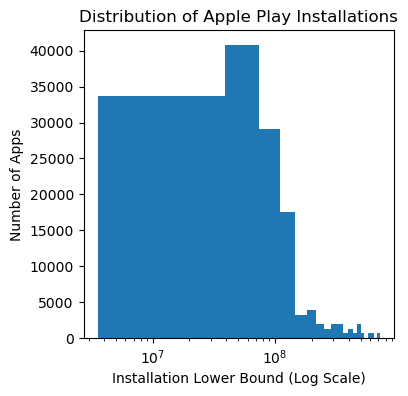

In [42]:
plt.figure(figsize=(4, 4))

plt.hist(
    comparison["Installation_Google"].dropna(),
    bins=20
)

plt.xscale("log")

plt.title(
    "Distribution of Google Play Installations"
)

plt.xlabel(
    "Installation Lower Bound (Log Scale)"
)

plt.ylabel("Number of Apps")

plt.show()
plt.figure(figsize=(4, 4))

plt.hist(
    comparison["Installation_Apple"].dropna(),
    bins=20
)

plt.xscale("log")

plt.title(
    "Distribution of Apple Play Installations"
)

plt.xlabel(
    "Installation Lower Bound (Log Scale)"
)

plt.ylabel("Number of Apps")

plt.show()

In [43]:
numeric_cols = [
    "Rating_Google",
    "Rating_Apple",
    "Installation_Google",
    "Installation_Apple"
]

correlation = comparison[numeric_cols].corr()

print(correlation)

                     Rating_Google  Rating_Apple  Installation_Google  \
Rating_Google         1.000000e+00  5.311825e-16         6.940515e-02   
Rating_Apple          5.311825e-16  1.000000e+00        -5.176041e-18   
Installation_Google   6.940515e-02 -5.176041e-18         1.000000e+00   
Installation_Apple   -1.250523e-16  1.459098e-01         4.160720e-17   

                     Installation_Apple  
Rating_Google             -1.250523e-16  
Rating_Apple               1.459098e-01  
Installation_Google        4.160720e-17  
Installation_Apple         1.000000e+00  


In [44]:
comparison.describe()

,Installation_Google,Installation_Apple,Rating_Google,Rating_Apple
count,1.425600e+05,1.425600e+05,142560.000000,142560.00000
mean,8.395637e+06,1.043098e+08,3.564198,3.52500
std,5.780986e+07,1.141050e+08,1.459388,1.05338
min,1.000000e+00,3.563520e+06,0.000000,0.00000
25%,1.000000e+03,4.091597e+07,3.600000,3.00000
50%,1.000000e+05,7.023104e+07,4.100000,4.00000
75%,1.000000e+06,1.136159e+08,4.400000,4.50000
max,1.000000e+09,7.143588e+08,5.000000,5.00000


In [45]:
comparison["Installation_Apple"].sum()

np.float64(14870408497128.0)

In [46]:
comparison["Installation_Google"].sum()

np.float64(1196881952860.0)

In [47]:
if (comparison["Installation_Apple"].sum())>(comparison["Installation_Google"].sum()):
         print("Apple has more installation")
else:
         print("Google has more installation")

Apple has more installation


# A/B-Style Platform Comparison: Apple vs Google Play

### Installation Potential — Apple vs Google Play for Entertainment Apps

H₀: There is no significant difference in installation levels
    between Apple and Google Play Entertainment apps.

H₁: There is a significant difference in installation levels
    between Apple and Google Play Entertainment apps.

In [48]:
from scipy.stats import ttest_ind
import numpy as np

# Group A: Apple
apple = comparison["Installation_Apple"].dropna()

# Group B: Google
google = comparison["Installation_Google"].dropna()

# Remove invalid zero values if zero means "missing"
apple = apple[apple > 0]
google = google[google > 0]

# Log transform because installation data is highly skewed
apple_log = np.log1p(apple)
google_log = np.log1p(google)

# Welch's two-sample t-test
t_stat, p_value = ttest_ind(
    apple_log,
    google_log,
    equal_var=False
)

print("Apple mean installs:", apple.mean())
print("Google mean installs:", google.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Installation levels differ significantly.")
else:
    print("Fail to reject H0: No significant difference.")

Apple mean installs: 104309823.91363636
Google mean installs: 8395636.594135802
T-statistic: 606.4674873481403
P-value: 0.0
Reject H0: Installation levels differ significantly.


## Google rating differ from Apple rating for entertainment app

In [49]:
from scipy.stats import ttest_ind

# A = Apple
apple_rating = comparison["Rating_Apple"].dropna()
apple_rating = apple_rating[apple_rating > 0]

# B = Google
google_rating = comparison["Rating_Google"].dropna()
google_rating = google_rating[google_rating > 0]

# Welch's t-test
t_stat, p_value = ttest_ind(
    apple_rating,
    google_rating,
    equal_var=False
)

print("Apple average rating :", apple_rating.mean())
print("Google average rating:", google_rating.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Ratings differ significantly.")
else:
    print("Fail to reject H0.")

Apple average rating : 3.6580188679245285
Google average rating: 4.095035460992908
T-statistic: -164.68583796500252
P-value: 0.0
Reject H0: Ratings differ significantly.


# Key Findings


1. Google Play shows a higher average rating.
Free Google Play apps have an average rating of 4.095, compared with 3.658 for Apple apps.

2. The rating difference is statistically significant.
The hypothesis test strongly rejects the assumption that both platforms have the same average rating.

3. User ratings alone should not determine the platform decision.
A higher rating does not necessarily mean a larger user base or greater advertising revenue.

4. Apple Play store has higher installation than Google play Store. Audience size is the most important business metric for this revenue model.
Since the company earns primarily from in-app advertising, the platform with more active users would potentially generate more advertising opportunities.
    